Jace Goode - Mini Project 3: Laptop Data Cleaning and Machine Learning
link to dataset: https://www.kaggle.com/code/shahriarkabir/data-cleaning

- What features/columns had a relatively even or normal distribution? Which features/columns did not?
- How did you handle missing values? Why did you do this method as opposed to others?
- How did you encode your categorical data? Why did you do this method as opposed to others?
- How did you handle removing outliers? Why did you use this method as opposed to others?
- How did you normalize/standardize the data? Why did you use this method as opposed to others?
- How did each model perform? Which performed the best?
- Did any models seem to have a relatively high amount of bias (underfitting)? Variance (overfitting)?

None of the numeric variables had normal looking distributions except for weight, although none of them were heavily skewed. However, price was somewhat right skewed, as it had a wide variety of prices. Before modeling, I fixed missing values by removing 30 rows that had missing observations for every column. I then removed another row that had a missing value for just inches. There were no columns that specifically had more missing values than others, and removing 31 values was a relatively small amount compared with the roughly 1250 total rows.

Outliers were removed using innerquartile range (1.5 innerquatlile distance away). This removed around 30 more observations. This method was chosen due to a lack of domain knowledge.

I encoded the categorical data using one-hot encoding dummy variables. This was done instead of label encoding as there was no need for specific ordering, as there were no ordinal variables. 

All of the numerical data was standardized using a mean of 0. This was done after splitting the data to avoid data leakage.

I used four models: linear regression, support vector regression, a decision tree, and a neural network. Their performance was very similar, each each earning high R^2 on the testing set, and lower on the training data. Linear regression had moderate variance but not high bias, as it fit the training data well while losing accuracy on the test data. The support vector model had both underfitting and poor generalization, so it had some bias and variance. The decision tree had extremely high variance, as shown by its good training performance and much weaker testing performance. The neural network also overfit, though not as dramatically as the tree.

The models each performed very poorly overall, especially on the testing set. The decision tree technically performed the best with the lowest RMSE and highest R^2. Despite high R^2, the models RMSE and MAE were very poor, and should not be used in any meaningful capacity. 

regression:
Training R²: 0.8672984621865383
Training RMSE (descaled): 11477.348339061642
Training MAE (descaled): 7948.365971164384
Linear Regression R²: 0.7487775738790552
Linear Regression RMSE (descaled): 16485.99419887025
Linear Regression MAE (descaled): 11866.109570130617

svm:
Training R²: 0.8748052155775858
Training RMSE (descaled): 11147.993407405722
Training MAE (descaled): 7175.557259251517

SVR R²: 0.6838779860003624
SVR RMSE (descaled): 18493.252954138206
SVR MAE (descaled): 12291.400192484572

decision tree: 
Training R²: 0.9991685782188846
Training RMSE (descaled): 908.4777259296973
Training MAE (descaled): 149.0403476861167

Decision Tree R²: 0.7711604554433649
Decision Tree RMSE (descaled): 15734.446763889446
Decision Tree MAE (descaled): 10760.413821686747

neural:
Training R²: 0.9696078484474482
Training RMSE (descaled): 5492.680125595875
Training MAE (descaled): 3172.5721236627573

MLP Regressor R²: 0.7156694428964241
MLP Regressor RMSE (descaled): 17538.71245638302
MLP Regressor MAE (descaled): 11792.483601988304


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import pickle

rawDF = pd.read_csv("laptopData.csv")
rawDF


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298.0,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,1299.0,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,1300.0,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,1301.0,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [2]:
import numpy as np 
import seaborn as sns

for aCol in rawDF:
    print(f"the amount of missing values in {aCol} is {rawDF[aCol].isna().sum()}")

the amount of missing values in Unnamed: 0 is 30
the amount of missing values in Company is 30
the amount of missing values in TypeName is 30
the amount of missing values in Inches is 30
the amount of missing values in ScreenResolution is 30
the amount of missing values in Cpu is 30
the amount of missing values in Ram is 30
the amount of missing values in Memory is 30
the amount of missing values in Gpu is 30
the amount of missing values in OpSys is 30
the amount of missing values in Weight is 30
the amount of missing values in Price is 30


In [3]:
rawDF.loc[pd.isna(rawDF.Company)]

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
cleanedDF = rawDF.dropna(how="all")



In [5]:
cleanedDF = cleanedDF.drop(columns=["Unnamed: 0"])


In [6]:
cleanedDF.isna().sum()


Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [7]:
# weight had kg so I removed that and converted the column to float
# also ran into erros because something had a question mark, so i replaced it with NaN

cleanedDF['Weight'] = cleanedDF['Weight'].replace('?', np.nan)

cleanedDF['Weight'] = cleanedDF['Weight'].str.replace('kg', '', regex=False)
cleanedDF['Weight'] = cleanedDF['Weight'].astype(float)
cleanedDF.isna().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              1
Price               0
dtype: int64

In [8]:
# redropping NaNs

cleanedDF = cleanedDF.dropna(how="any")
cleanedDF.isna().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [9]:
Q1 = cleanedDF['Price'].quantile(0.25)
Q3 = cleanedDF['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [10]:
outlierDF = cleanedDF[
    (cleanedDF['Price'] >= lower_bound) &
    (cleanedDF['Price'] <= upper_bound)
].copy()


In [11]:
print("Rows before outlier removal:", cleanedDF.shape[0])
print("Rows after outlier removal:", outlierDF.shape[0])
print("Rows removed:", cleanedDF.shape[0] - outlierDF.shape[0])


Rows before outlier removal: 1272
Rows after outlier removal: 1244
Rows removed: 28


In [12]:
# after trying to plot dist plots, i realized that memory, ram, and inches were not numeric still
# convert inches to numeric
outlierDF['Inches'] = pd.to_numeric(outlierDF['Inches'], errors='coerce')


In [13]:
# removing GB then convert to int

outlierDF['Ram'] = (
    outlierDF['Ram']
    .str.replace('GB', '', regex=False)
    .str.strip()
    .astype(int)
)


In [14]:
# complicated code I got from AI to fix the memory names

def convert_memory_to_gb(mem_string):
    if pd.isna(mem_string):
        return np.nan
    
    # Normalize
    mem_string = mem_string.upper().replace(" ", "")
    
    # Remove drive-type labels
    for label in ["SSD", "HDD", "FLASH", "HYBRID", "STORAGE"]:
        mem_string = mem_string.replace(label, "")
    
    total_gb = 0
    
    # Split on '+'
    parts = mem_string.split('+')
    
    for part in parts:
        if "TB" in part:
            num = float(part.replace("TB", ""))
            total_gb += num * 1024
        elif "GB" in part:
            num = float(part.replace("GB", ""))
            total_gb += num
    
    return total_gb

outlierDF["Memory_GB"] = outlierDF["Memory"].apply(convert_memory_to_gb)



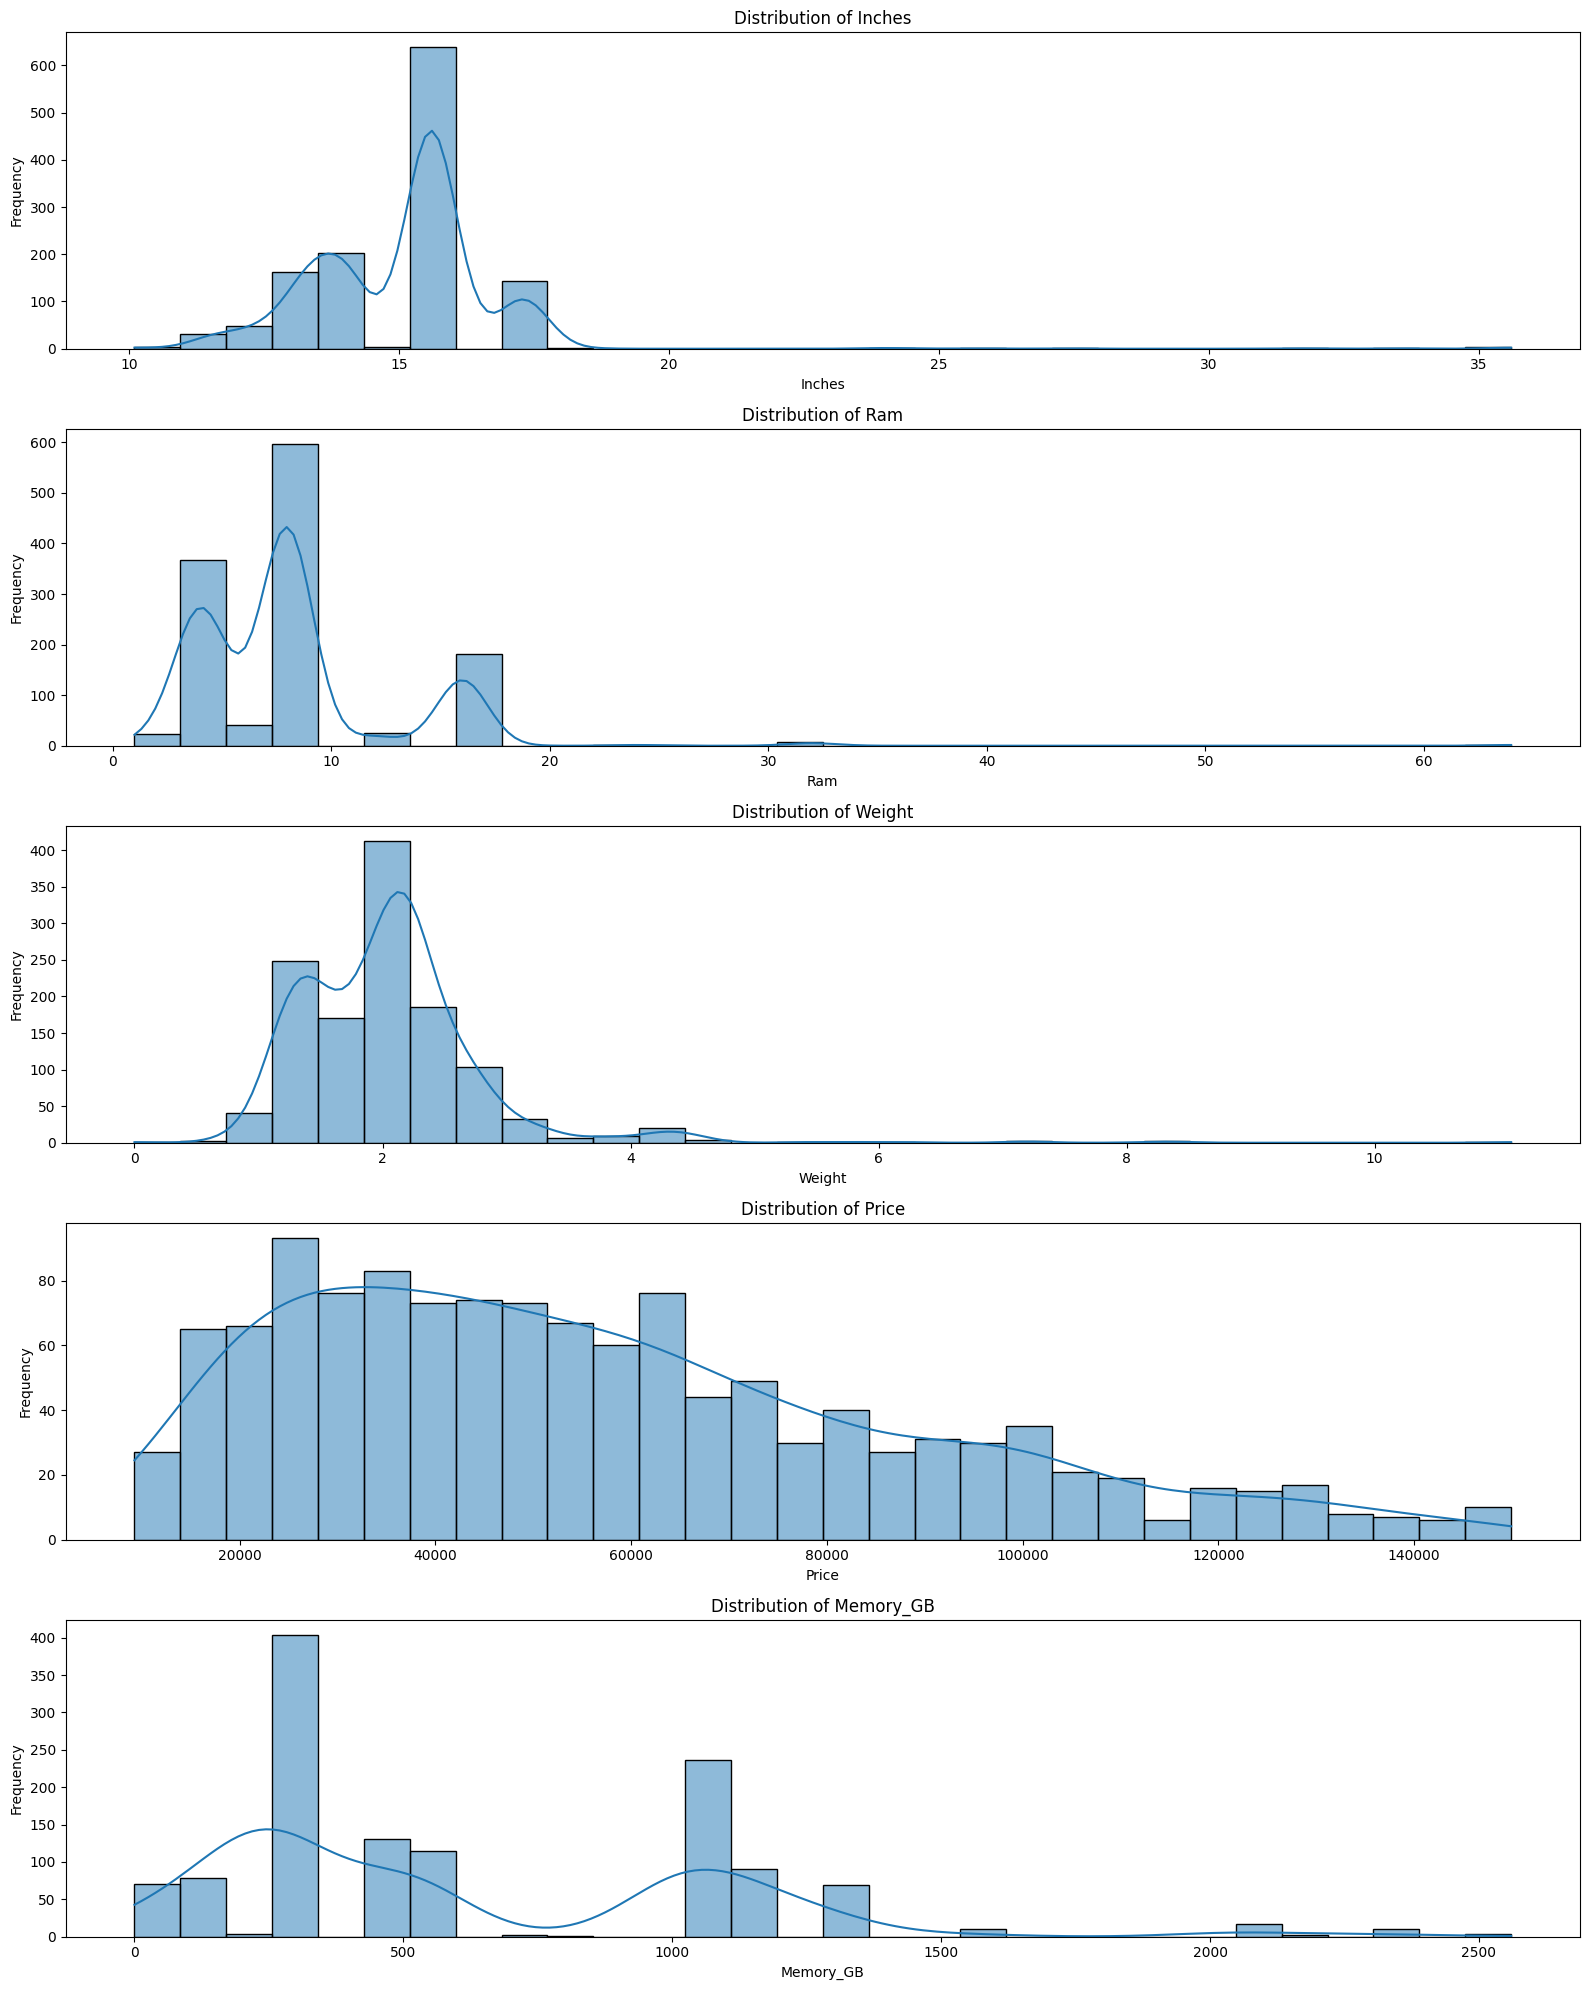

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# numeric columns before encoding
numeric_cols = outlierDF.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(16, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.histplot(outlierDF[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



In [16]:
outlierDF = outlierDF.drop(columns=['Memory'])
outlierDF.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Gpu,OpSys,Weight,Price,Memory_GB
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,128.0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,128.0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,Intel HD Graphics 620,No OS,1.86,30636.0000,256.0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,512.0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,256.0


In [17]:
# made variable for cat columns, then dropped original memory column because i made a new one
categorical_cols = outlierDF.select_dtypes(include=['object']).columns
categorical_cols


Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Gpu', 'OpSys'], dtype='object')

In [18]:
# easy way of encoding dummies

encodedDF = pd.get_dummies(outlierDF, columns=categorical_cols, drop_first=True)



In [19]:
encodedDF.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1244 entries, 0 to 1302
Columns: 290 entries, Inches to OpSys_macOS
dtypes: bool(285), float64(4), int64(1)
memory usage: 404.5 KB


In [20]:
encodedDF.select_dtypes(include='bool').columns.tolist()


['Company_Apple',
 'Company_Asus',
 'Company_Chuwi',
 'Company_Dell',
 'Company_Fujitsu',
 'Company_Google',
 'Company_HP',
 'Company_Huawei',
 'Company_LG',
 'Company_Lenovo',
 'Company_MSI',
 'Company_Mediacom',
 'Company_Microsoft',
 'Company_Razer',
 'Company_Samsung',
 'Company_Toshiba',
 'Company_Vero',
 'Company_Xiaomi',
 'TypeName_Gaming',
 'TypeName_Netbook',
 'TypeName_Notebook',
 'TypeName_Ultrabook',
 'TypeName_Workstation',
 'ScreenResolution_1440x900',
 'ScreenResolution_1600x900',
 'ScreenResolution_1920x1080',
 'ScreenResolution_2560x1440',
 'ScreenResolution_4K Ultra HD / Touchscreen 3840x2160',
 'ScreenResolution_4K Ultra HD 3840x2160',
 'ScreenResolution_Full HD / Touchscreen 1920x1080',
 'ScreenResolution_Full HD 1920x1080',
 'ScreenResolution_IPS Panel 1366x768',
 'ScreenResolution_IPS Panel 2560x1440',
 'ScreenResolution_IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
 'ScreenResolution_IPS Panel 4K Ultra HD 3840x2160',
 'ScreenResolution_IPS Panel Full HD / Touch

In [21]:
encodedDF.select_dtypes(include='float64').columns.tolist()

['Inches', 'Weight', 'Price', 'Memory_GB']

In [22]:
encodedDF.select_dtypes(include='int64').columns.tolist()

['Ram']

In [23]:
# i ran into another error when running the models because of one NA in inches so i removed it here

encodedDF = encodedDF.dropna(subset=["Inches"])


In [24]:
# encodedDF is now ready for modeling
# it includes removed outliers, converted numeric columns, no NAs, and encoded features

xDF = encodedDF.drop(columns=["Price"])
yDF = encodedDF[["Price"]]


In [25]:
print("xDF shape:", xDF.shape)
print("yDF shape:", yDF.shape)

xDF shape: (1243, 289)
yDF shape: (1243, 1)


In [26]:
from sklearn.model_selection import train_test_split

xTrain, xTest, yTrain, yTest = train_test_split(
                                            xDF,
                                            yDF,
                                            test_size=0.2,
                                            random_state=5)

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn import tree
from sklearn.neural_network import MLPRegressor

scalerX = StandardScaler()
scalerY = StandardScaler()

standardizedTrainDF = xTrain.copy()
standardizedTestDF = xTest.copy()

standardizedTrainDF[xTrain.columns] = scalerX.fit_transform(xTrain)
standardizedTestDF[xTest.columns] = scalerX.transform(xTest)

yTrainScaled = scalerY.fit_transform(yTrain)
yTestScaled = scalerY.transform(yTest)

In [28]:
standardizedTestDF.isna().sum().sort_values(ascending=False).head(10)


Inches             0
Ram                0
Weight             0
Memory_GB          0
Company_Apple      0
Company_Asus       0
Company_Chuwi      0
Company_Dell       0
Company_Fujitsu    0
Company_Google     0
dtype: int64

In [29]:
# Linear Regression
model = LinearRegression().fit(standardizedTrainDF, yTrainScaled)
preds = model.predict(standardizedTestDF)

train_preds = model.predict(standardizedTrainDF)

train_preds_descaled = scalerY.inverse_transform(train_preds.reshape(-1,1))
yTrain_descaled = scalerY.inverse_transform(yTrainScaled)

print("Training R²:", r2_score(yTrainScaled, train_preds))
print("Training RMSE (descaled):", np.sqrt(mean_squared_error(yTrain_descaled, train_preds_descaled)))
print("Training MAE (descaled):", mean_absolute_error(yTrain_descaled, train_preds_descaled))

# DESCALING
preds_descaled = scalerY.inverse_transform(preds.reshape(-1,1))
yTest_descaled = scalerY.inverse_transform(yTestScaled)

print("Linear Regression R²:", r2_score(yTestScaled, preds))
print("Linear Regression RMSE (descaled):", np.sqrt(mean_squared_error(yTest_descaled, preds_descaled)))
print("Linear Regression MAE (descaled):", mean_absolute_error(yTest_descaled, preds_descaled))


Training R²: 0.8672984621865383
Training RMSE (descaled): 11477.348339061642
Training MAE (descaled): 7948.365971164384
Linear Regression R²: 0.7487775738790552
Linear Regression RMSE (descaled): 16485.99419887025
Linear Regression MAE (descaled): 11866.109570130617


In [30]:
model = SVR().fit(standardizedTrainDF, yTrainScaled.ravel())
preds = model.predict(standardizedTestDF)

train_preds = model.predict(standardizedTrainDF)

train_preds_descaled = scalerY.inverse_transform(train_preds.reshape(-1,1))
yTrain_descaled = scalerY.inverse_transform(yTrainScaled)

print("Training R²:", r2_score(yTrainScaled, train_preds))
print("Training RMSE (descaled):", np.sqrt(mean_squared_error(yTrain_descaled, train_preds_descaled)))
print("Training MAE (descaled):", mean_absolute_error(yTrain_descaled, train_preds_descaled))

# DESCALING
preds_descaled = scalerY.inverse_transform(preds.reshape(-1,1))
yTest_descaled = scalerY.inverse_transform(yTestScaled)

print("\nSVR R²:", r2_score(yTestScaled, preds))
print("SVR RMSE (descaled):", np.sqrt(mean_squared_error(yTest_descaled, preds_descaled)))
print("SVR MAE (descaled):", mean_absolute_error(yTest_descaled, preds_descaled))

Training R²: 0.8748052155775858
Training RMSE (descaled): 11147.993407405722
Training MAE (descaled): 7175.557259251517

SVR R²: 0.6838779860003624
SVR RMSE (descaled): 18493.252954138206
SVR MAE (descaled): 12291.400192484572


In [31]:
model = tree.DecisionTreeRegressor(random_state=5).fit(
    standardizedTrainDF,
    yTrainScaled
)
preds = model.predict(standardizedTestDF)

train_preds = model.predict(standardizedTrainDF)

train_preds_descaled = scalerY.inverse_transform(train_preds.reshape(-1,1))
yTrain_descaled = scalerY.inverse_transform(yTrainScaled)

print("Training R²:", r2_score(yTrainScaled, train_preds))
print("Training RMSE (descaled):", np.sqrt(mean_squared_error(yTrain_descaled, train_preds_descaled)))
print("Training MAE (descaled):", mean_absolute_error(yTrain_descaled, train_preds_descaled))

# DESCALING
preds_descaled = scalerY.inverse_transform(preds.reshape(-1,1))
yTest_descaled = scalerY.inverse_transform(yTestScaled)

print("\nDecision Tree R²:", r2_score(yTestScaled, preds))
print("Decision Tree RMSE (descaled):", np.sqrt(mean_squared_error(yTest_descaled, preds_descaled)))
print("Decision Tree MAE (descaled):", mean_absolute_error(yTest_descaled, preds_descaled))


Training R²: 0.9991685782188846
Training RMSE (descaled): 908.4777259296973
Training MAE (descaled): 149.0403476861167

Decision Tree R²: 0.7711604554433649
Decision Tree RMSE (descaled): 15734.446763889446
Decision Tree MAE (descaled): 10760.413821686747


In [32]:
model = MLPRegressor(max_iter=2000, random_state=5).fit(
    standardizedTrainDF,
    yTrainScaled.ravel()
)
preds = model.predict(standardizedTestDF)

train_preds = model.predict(standardizedTrainDF)

train_preds_descaled = scalerY.inverse_transform(train_preds.reshape(-1,1))
yTrain_descaled = scalerY.inverse_transform(yTrainScaled)

print("Training R²:", r2_score(yTrainScaled, train_preds))
print("Training RMSE (descaled):", np.sqrt(mean_squared_error(yTrain_descaled, train_preds_descaled)))
print("Training MAE (descaled):", mean_absolute_error(yTrain_descaled, train_preds_descaled))

# DESCALING
preds_descaled = scalerY.inverse_transform(preds.reshape(-1,1))
yTest_descaled = scalerY.inverse_transform(yTestScaled)

print("\nMLP Regressor R²:", r2_score(yTestScaled, preds))
print("MLP Regressor RMSE (descaled):", np.sqrt(mean_squared_error(yTest_descaled, preds_descaled)))
print("MLP Regressor MAE (descaled):", mean_absolute_error(yTest_descaled, preds_descaled))

Training R²: 0.9696078484474482
Training RMSE (descaled): 5492.680125595875
Training MAE (descaled): 3172.5721236627573

MLP Regressor R²: 0.7156694428964241
MLP Regressor RMSE (descaled): 17538.71245638302
MLP Regressor MAE (descaled): 11792.483601988304
